<a href="https://colab.research.google.com/github/wailbenelhassane/Diabetes-Detector/blob/main/Diabetes_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the dependencies

In [73]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

Data Collection and Analysis  


The PIMA dataset contains information about female patients of Pima descent, with the goal of predicting the presence of diabetes. The columns are:

- **Pregnancies**: Number of pregnancies.
- **Glucose**: Blood glucose level.
- **BloodPressure**: Blood pressure (mmHg).
- **SkinThickness**: Skin thickness (mm).
- **Insulin**: Insulin level (mu U/ml).
- **BMI**: Body Mass Index.
- **DiabetesPedigreeFunction**: Diabetes pedigree function (genetic heritage).
- **Age**: Age in years.
- **Outcome**: Result (0 = Non-diabetic, 1 = Diabetic).

In [74]:
#loading the dataset to a pandas DataFrame
diabetes_dataset = pd.read_csv('/content/dataset.csv')

diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Dataset analysis

In [75]:
print("Dataset Info:")
print(diabetes_dataset.info())
print("\nMissing Values:")
print(diabetes_dataset.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction

Dataset Cleaning

In [76]:
# Replace zeros with NaN for columns where zero is invalid
columns_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes_dataset[columns_with_invalid_zeros] = diabetes_dataset[columns_with_invalid_zeros].replace(0, np.nan)

In [77]:
# Impute missing values with median (avoiding inplace warning)
for column in columns_with_invalid_zeros:
    diabetes_dataset[column] = diabetes_dataset[column].fillna(diabetes_dataset[column].median())

In [78]:
# Check for outliers using IQR
Q1 = diabetes_dataset.quantile(0.25)
Q3 = diabetes_dataset.quantile(0.75)
IQR = Q3 - Q1
outlier_condition = (diabetes_dataset < (Q1 - 1.5 * IQR)) | (diabetes_dataset > (Q3 + 1.5 * IQR))
print("\nOutliers Count per Column:")
print(outlier_condition.sum())


Outliers Count per Column:
Pregnancies                   4
Glucose                       0
BloodPressure                14
SkinThickness                87
Insulin                     346
BMI                           8
DiabetesPedigreeFunction     29
Age                           9
Outcome                       0
dtype: int64


In [ ]:
# Cap outliers
for column in diabetes_dataset.columns:
    lower_bound = Q1[column] - 1.5 * IQR[column]
    upper_bound = Q3[column] + 1.5 * IQR[column]
    diabetes_dataset[column] = diabetes_dataset[column].clip(lower=lower_bound, upper=upper_bound)

In [79]:
print("\nDataset After Cleaning:")
print(diabetes_dataset.describe())


Dataset After Cleaning:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.455208                  0.471876   33.240885    0.348958  
std      6.875177                  0.331329   11.760232    0.476951  
min     18

In [80]:
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


0 -> Non-Diabetic  

1 -> Diabetic

In [81]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164


Data Visualization

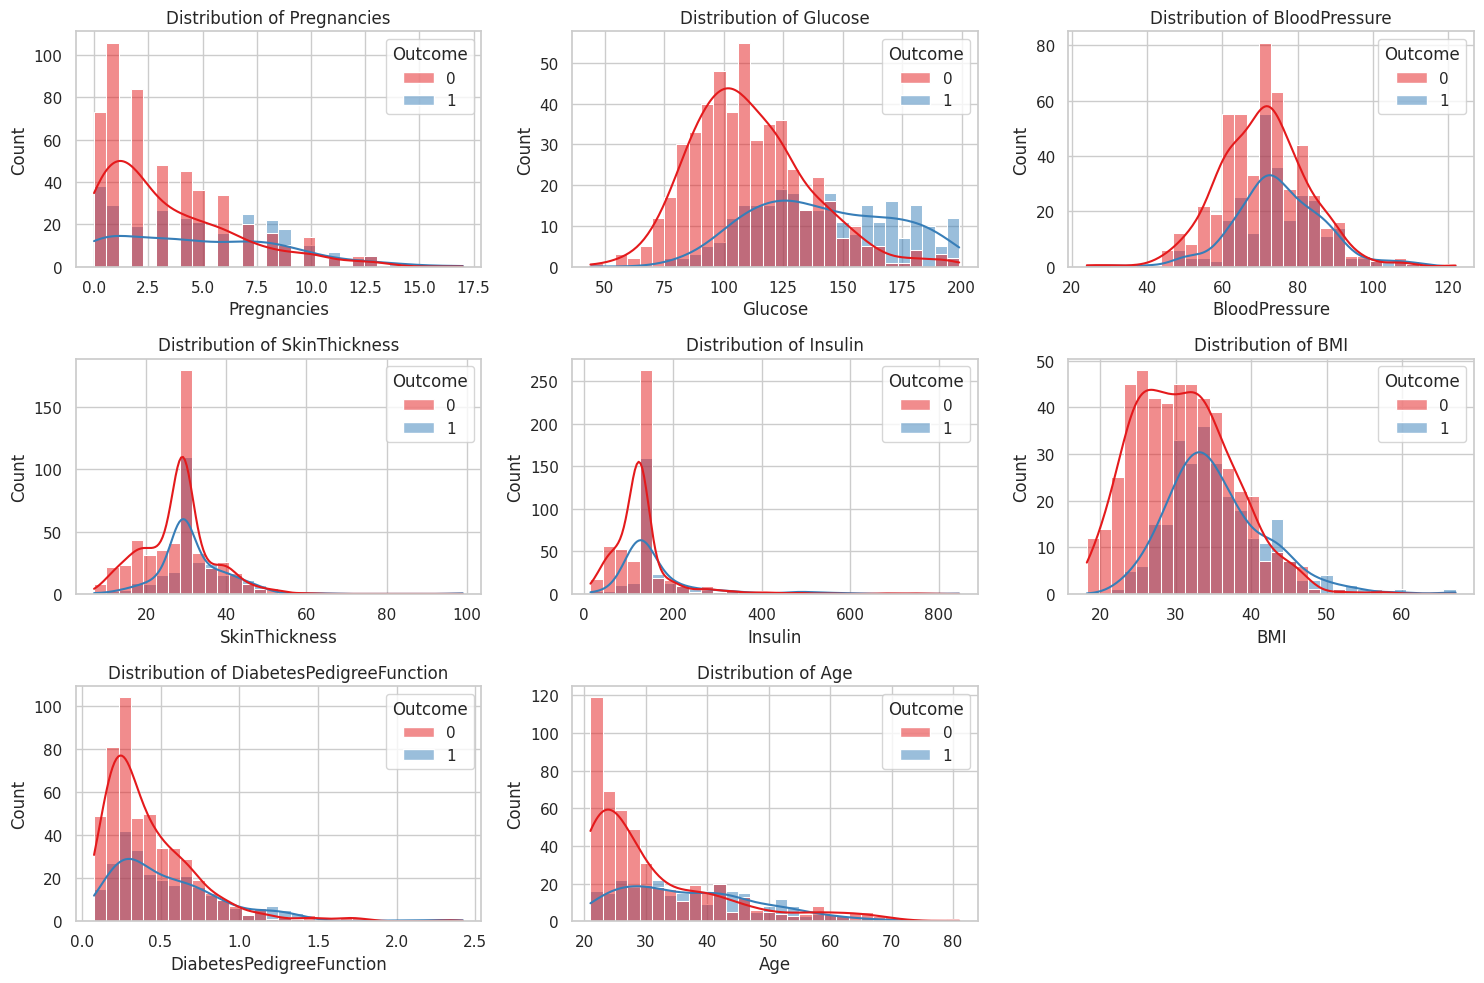

In [82]:
# Variable distribution
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))
for i, column in enumerate(diabetes_dataset.columns[:-1], 1):  # Exclude Outcome
    plt.subplot(3, 3, i)
    sns.histplot(data=diabetes_dataset, x=column, hue='Outcome', kde=True, bins=30, palette='Set1')
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

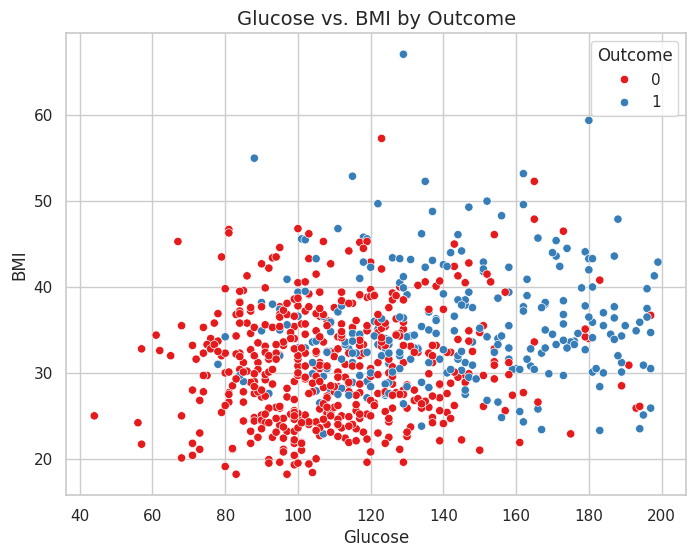

In [83]:
# Scatter plot showing Glucose vs. BMI
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=diabetes_dataset, palette='Set1')
plt.title('Glucose vs. BMI by Outcome', fontsize=14)
plt.show()

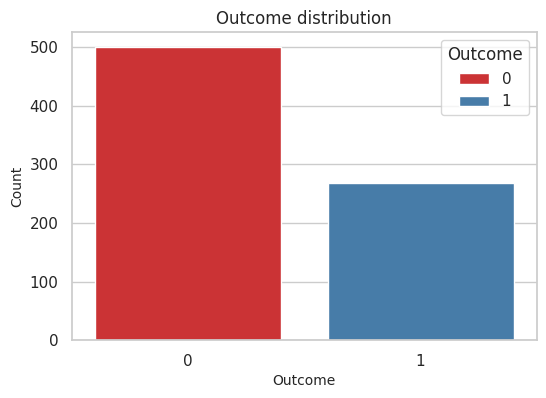

In [84]:
# Outcome distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', hue='Outcome', data=diabetes_dataset, palette='Set1', legend=True)
plt.title('Outcome distribution', fontsize=12)
plt.xlabel('Outcome', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.show()

Separating the data for training

In [85]:
X = diabetes_dataset.drop('Outcome', axis=1)
y = diabetes_dataset['Outcome']

In [86]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6    148.0           72.0           35.0    125.0  33.6   
1              1     85.0           66.0           29.0    125.0  26.6   
2              8    183.0           64.0           29.0    125.0  23.3   
3              1     89.0           66.0           23.0     94.0  28.1   
4              0    137.0           40.0           35.0    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10    101.0           76.0           48.0    180.0  32.9   
764            2    122.0           70.0           27.0    125.0  36.8   
765            5    121.0           72.0           23.0    112.0  26.2   
766            1    126.0           60.0           29.0    125.0  30.1   
767            1     93.0           70.0           31.0    125.0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [87]:
print(y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Splitting the Data into Train and Test

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Data Standarization

In [89]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Defining Models

In [90]:
models = {
    'SVM': SVC(kernel='linear', random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

Train and evaluate models


<Figure size 600x400 with 0 Axes>

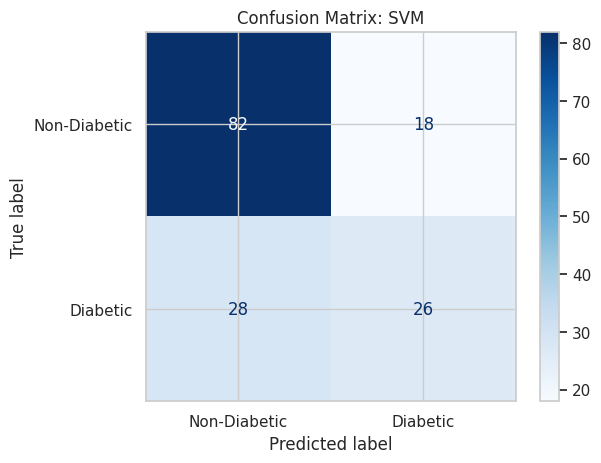

<Figure size 600x400 with 0 Axes>

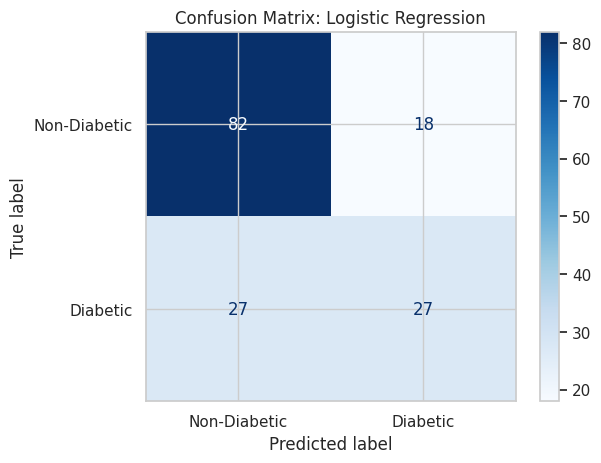

<Figure size 600x400 with 0 Axes>

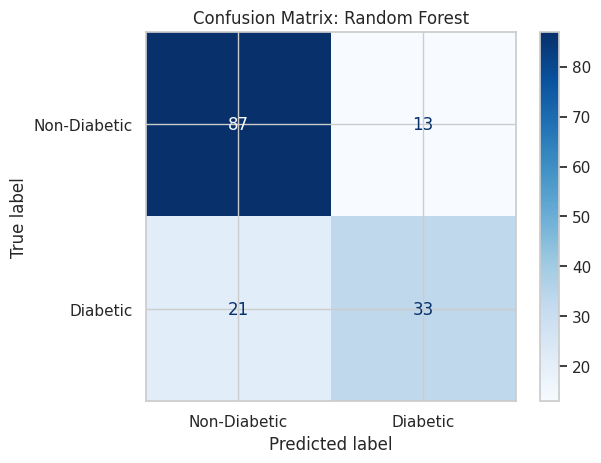

<Figure size 600x400 with 0 Axes>

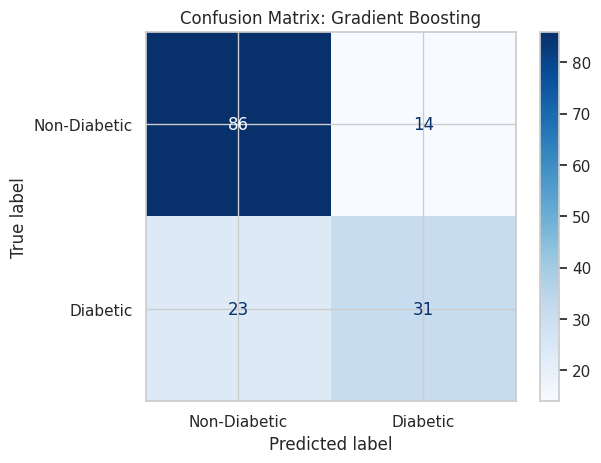

In [91]:
results = {}
for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    # Store results
    results[name] = {
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Cross-Val Mean': cv_scores.mean(),
        'Cross-Val Std': cv_scores.std(),
        'Classification Report': classification_report(y_test, y_test_pred, output_dict=True)
    }

    # Confusion Matrix
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_test, y_test_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Non-Diabetic', 'Diabetic']).plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

Visualize model comparison


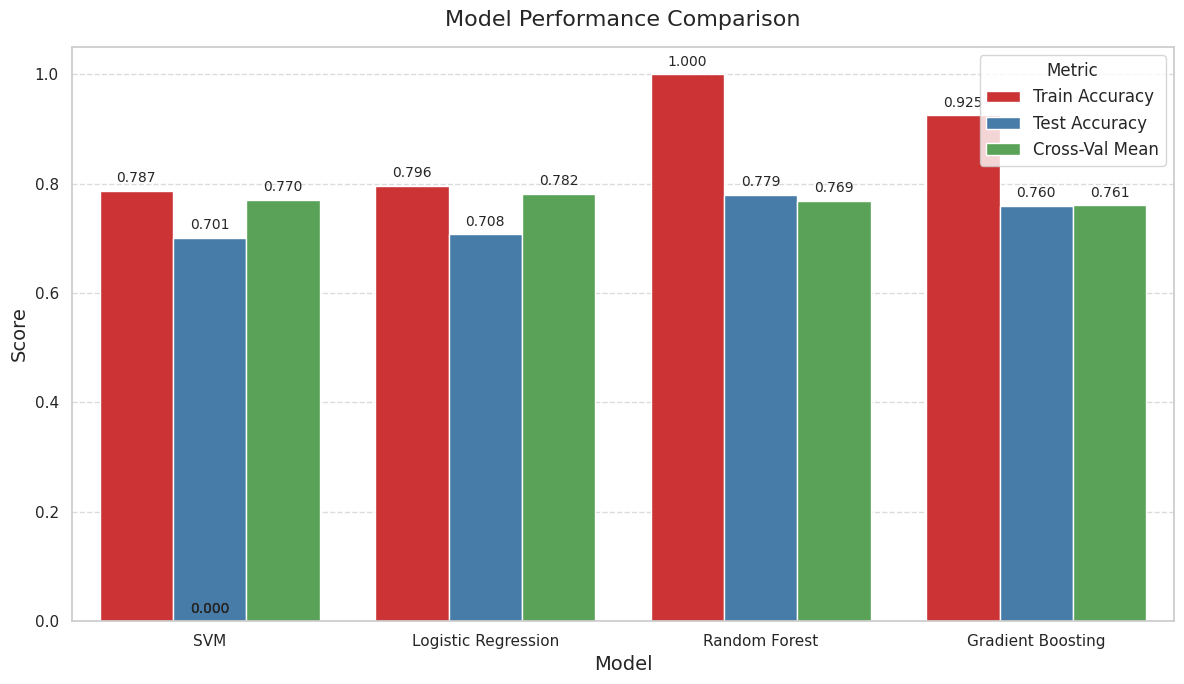

In [93]:
plot_data = []
for model in models:
    for metric in ['Train Accuracy', 'Test Accuracy', 'Cross-Val Mean']:
        plot_data.append({
            'Model': model,
            'Metric': metric,
            'Score': results[model][metric],
            'Std': results[model].get('Cross-Val Std', 0) if metric == 'Cross-Val Mean' else 0
        })
plot_df = pd.DataFrame(plot_data)

# Plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=plot_df, palette='Set1')
plt.title('Model Performance Comparison', fontsize=16, pad=15)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.ylim(0, 1.05)
plt.legend(title='Metric', fontsize=12, title_fontsize=12, loc='upper right')

# Add annotations on bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}',
                       (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                       ha='center', va='bottom', fontsize=10)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Making a Predictive System

In [94]:
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Select best model based on Test Accuracy
best_model_name = max(results, key=lambda x: results[x]['Test Accuracy'])
best_model = models[best_model_name]
print(f"Selected model for prediction: {best_model_name} (Test Accuracy: {results[best_model_name]['Test Accuracy']:.4f})")

# Predictive function
def predict_diabetes(input_data, feature_names, scaler, model, columns_with_invalid_zeros, dataset):
    try:
        # Convert input to DataFrame
        input_data_df = pd.DataFrame([input_data], columns=feature_names)

        # Validate input
        if len(input_data) != len(feature_names):
            raise ValueError(f"Input must have {len(feature_names)} features, got {len(input_data)}")
        for val in input_data:
            if not isinstance(val, (int, float)) or val < 0:
                raise ValueError("All input values must be non-negative numbers")

        # Clean input: replace invalid zeros with median from dataset
        for column in columns_with_invalid_zeros:
            if input_data_df[column].iloc[0] == 0:
                input_data_df[column] = dataset[column].median()

        # Standardize input
        std_data = scaler.transform(input_data_df)

        # Predict
        prediction = model.predict(std_data)
        result = 'Non-Diabetic' if prediction[0] == 0 else 'Diabetic'

        # Get probabilities (if available)
        prob_message = ""
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(std_data)[0]
            prob_message = f"Confidence: Non-Diabetic: {probs[0]:.4f}, Diabetic: {probs[1]:.4f}"

        # Feature contributions (for tree-based models)
        contrib_message = ""
        if best_model_name in ['Random Forest', 'Gradient Boosting']:
            importances = model.feature_importances_
            contrib = std_data[0] * importances  # Approximate contribution
            contrib_df = pd.DataFrame({
                'Feature': feature_names,
                'Contribution': contrib
            }).sort_values(by='Contribution', key=abs, ascending=False)
            contrib_message = f"\nFeature Contributions:\n{contrib_df.to_string(index=False)}"

        # Format output
        print("\nPrediction Results:")
        print(f"Input Data: {input_data}")
        print(f"Result: {result}")
        if prob_message:
            print(prob_message)
        if contrib_message:
            print(contrib_message)

        return prediction[0]

    except Exception as e:
        print(f"Prediction error: {e}")
        return None

# Example prediction
input_data = (1, 89, 66, 23, 94, 28.1, 0.167, 21)
columns_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
predict_diabetes(input_data, feature_names, scaler, best_model, columns_with_invalid_zeros, diabetes_dataset)

Selected model for prediction: Random Forest (Test Accuracy: 0.7792)

Prediction Results:
Input Data: (1, 89, 66, 23, 94, 28.1, 0.167, 21)
Result: Non-Diabetic
Confidence: Non-Diabetic: 0.9600, Diabetic: 0.0400

Feature Contributions:
                 Feature  Contribution
                 Glucose     -0.298694
                     Age     -0.118170
DiabetesPedigreeFunction     -0.117595
                     BMI     -0.103211
             Pregnancies     -0.068785
                 Insulin     -0.050660
           SkinThickness     -0.047925
           BloodPressure     -0.041810


np.int64(0)